In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
# Make your plots look crisp and beautiful
plt.style.use('ggplot')
sns.set_palette("deep") 


In [2]:
# Load the dataset
df = pd.read_csv("/Users/millicentomondi/Documents/AI_Saturdays_Exercises/EDA_BMW_Sales/BMW_sales.csv")
#first 5 rows
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [4]:
#last 5 rows
df.tail()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High
49999,X1,2020,North America,Blue,Diesel,Manual,3.3,171003,77492,1764,Low


In [5]:
#shape of dataset
df.shape

(50000, 11)

In [6]:
# Data types of each column
df.dtypes

Model                    object
Year                      int64
Region                   object
Color                    object
Fuel_Type                object
Transmission             object
Engine_Size_L           float64
Mileage_KM                int64
Price_USD                 int64
Sales_Volume              int64
Sales_Classification     object
dtype: object

In [7]:
# Summary statistics of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,50000.0,2017.01570,4.324459,2010.0,2013.00,2017.0,2021.00,2024.0
Engine_Size_L,50000.0,3.24718,1.009078,1.5,2.40,3.2,4.10,5.0
Mileage_KM,50000.0,100307.20314,57941.509344,3.0,50178.00,100388.5,150630.25,199996.0
Price_USD,50000.0,75034.60090,25998.248882,30000.0,52434.75,75011.5,97628.25,119998.0
Sales_Volume,50000.0,5067.51468,2856.767125,100.0,2588.00,5087.0,7537.25,9999.0


In [8]:
#info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [9]:
# check for missing values
df.isnull().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

In [10]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis
- Sales Per year
- Sales per region /car
- Number of transmissions
- Number of transmissions per region
- Sales per mileage
- Slaes Classifiv=cation (High/Low)
- Which regions had high sales and why and vice versa
- Sales per model

In [11]:
# Check for unique values in each column
df.nunique()

Model                      11
Year                       15
Region                      6
Color                       6
Fuel_Type                   4
Transmission                2
Engine_Size_L              36
Mileage_KM              44347
Price_USD               38246
Sales_Volume             9845
Sales_Classification        2
dtype: int64

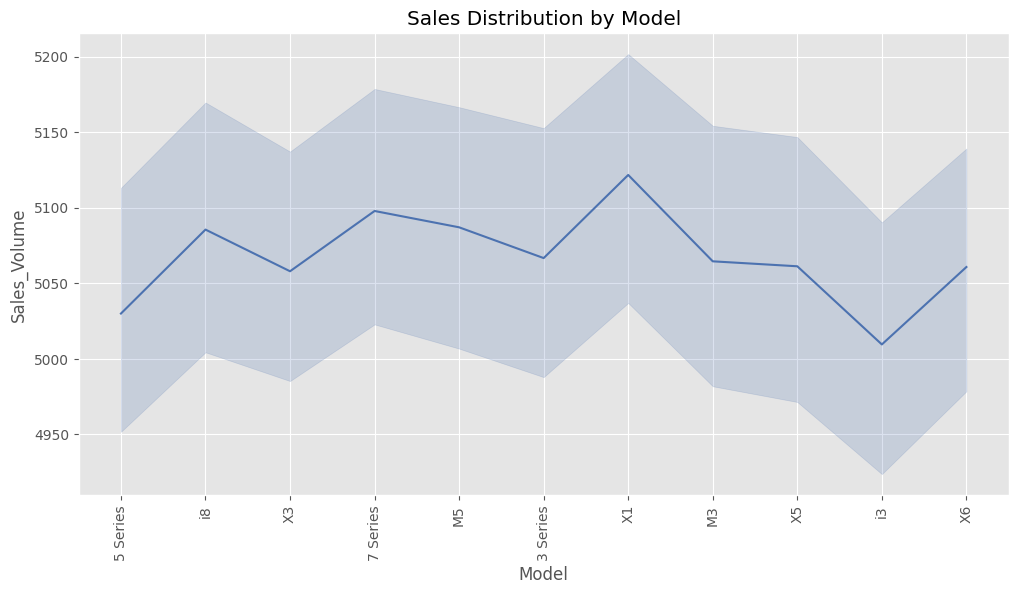

In [12]:
# plot model vs sales
plt.figure(figsize=(12, 6))
sns.lineplot(x='Model', y='Sales_Volume', data=df)
plt.xticks(rotation=90)
plt.title('Sales Distribution by Model')
plt.show()

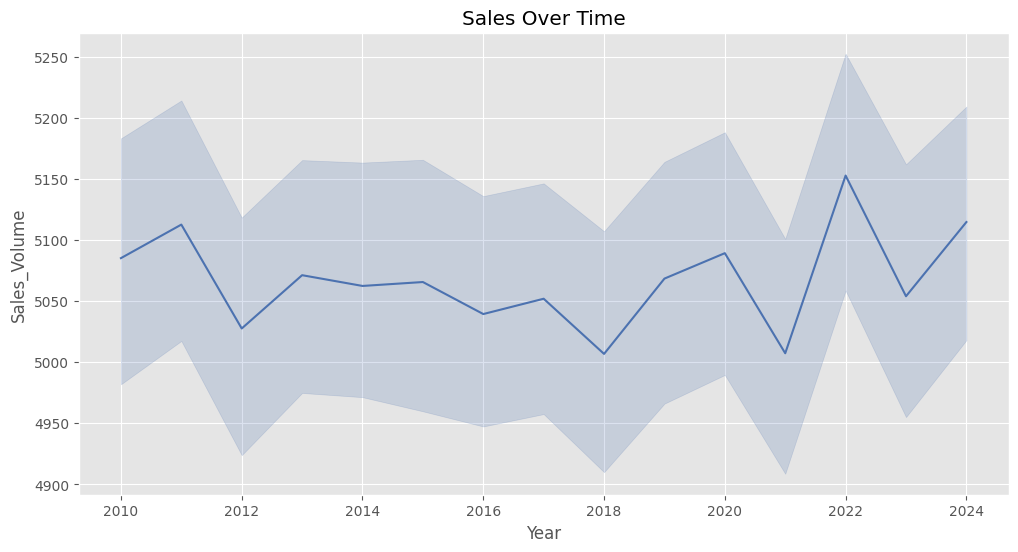

In [13]:
# plot sales over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Sales_Volume', data=df)
plt.title('Sales Over Time')
plt.show()

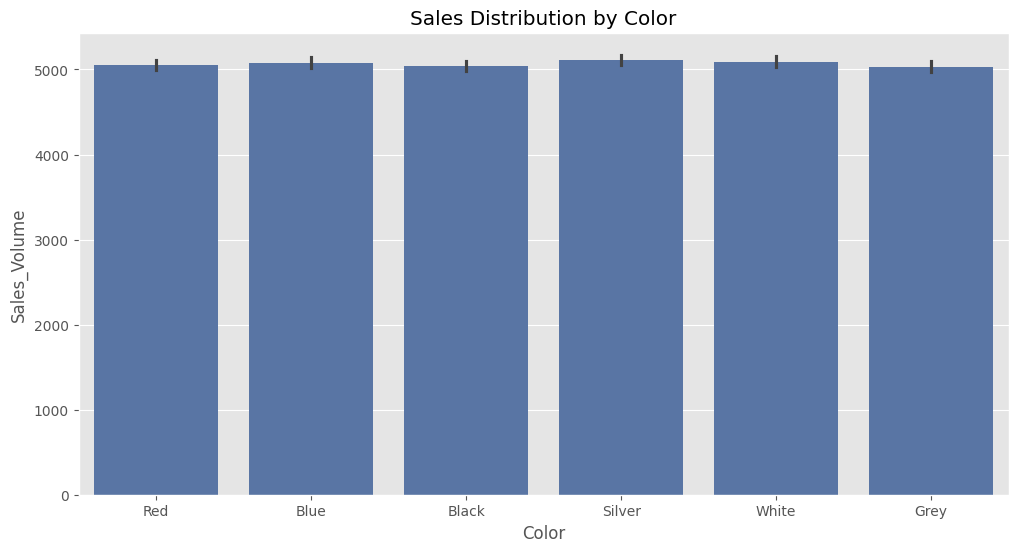

In [14]:

#plot sales by color
plt.figure(figsize=(12, 6))
sns.barplot(x='Color', y='Sales_Volume', data=df)
plt.title('Sales Distribution by Color')

plt.show()



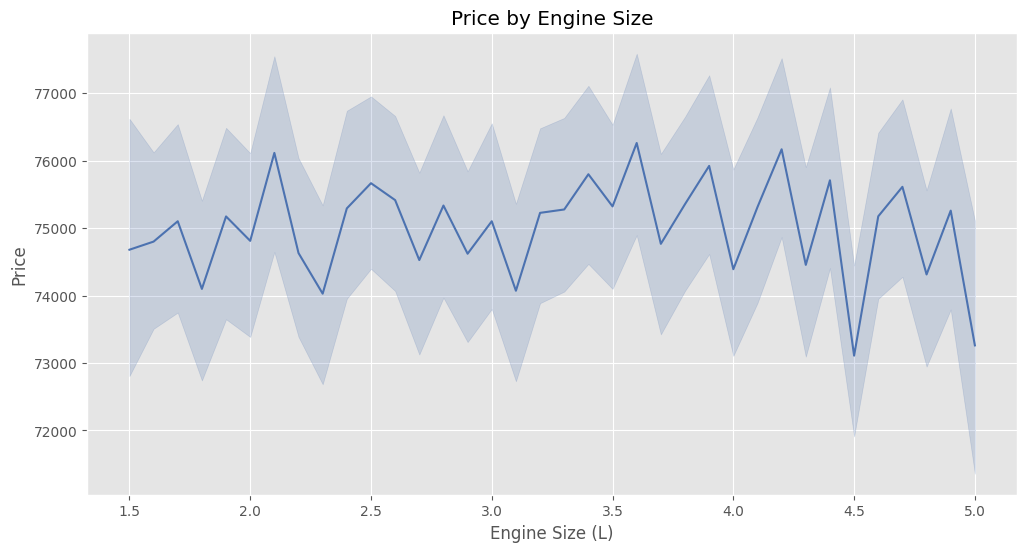

In [15]:
# scatter plot engine size vs price
plt.figure(figsize=(12, 6))
sns.lineplot(x='Engine_Size_L', y='Price_USD', data=df)
plt.title('Price by Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price')
plt.show()

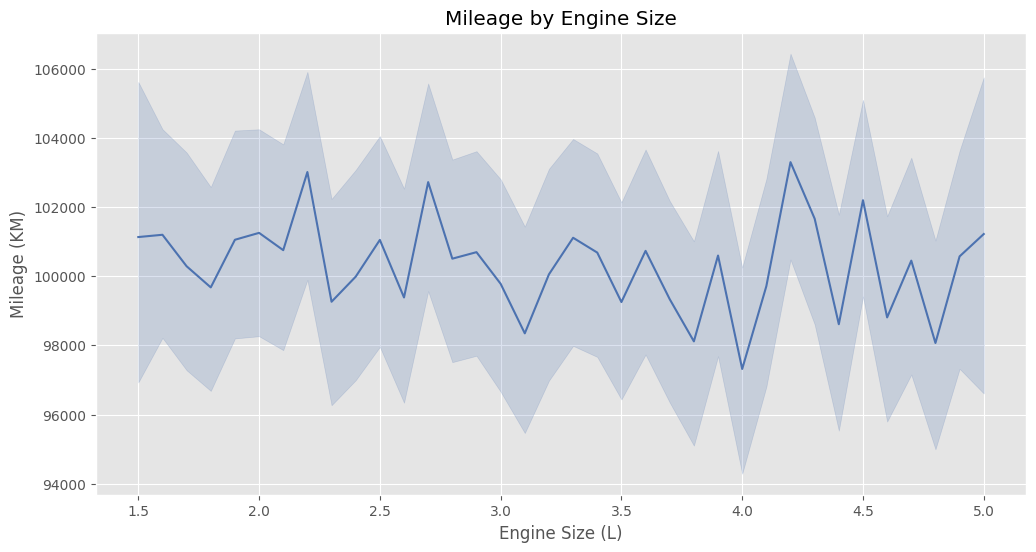

In [16]:
#scatter plot of engine size vs mileage
plt.figure(figsize=(12, 6))
sns.lineplot(x='Engine_Size_L', y='Mileage_KM', data=df)
plt.title('Mileage by Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('Mileage (KM)')
plt.show()

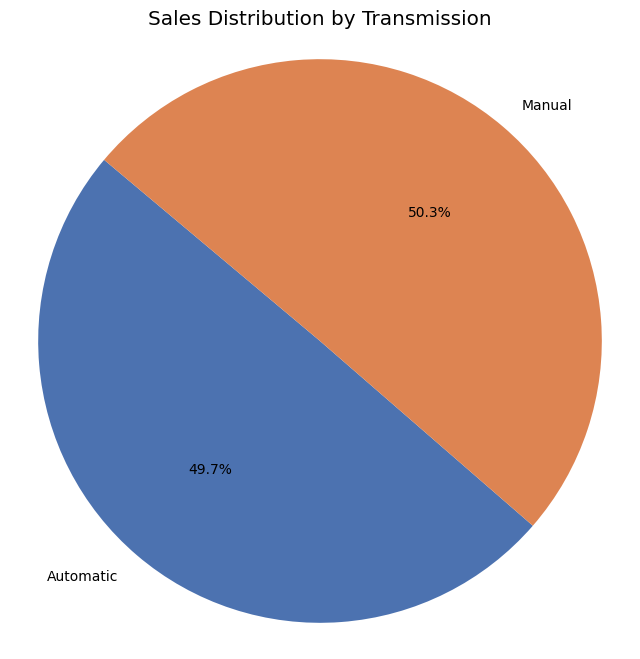

In [17]:
# plot sales per transmission
transmission_sales = df.groupby('Transmission')['Sales_Volume'].sum()
plt.figure(figsize=(8, 8))
plt.pie(transmission_sales, labels=transmission_sales.index, autopct='%1.1f%%', startangle=140)
plt.title('Sales Distribution by Transmission')
plt.axis('equal')
plt.show()


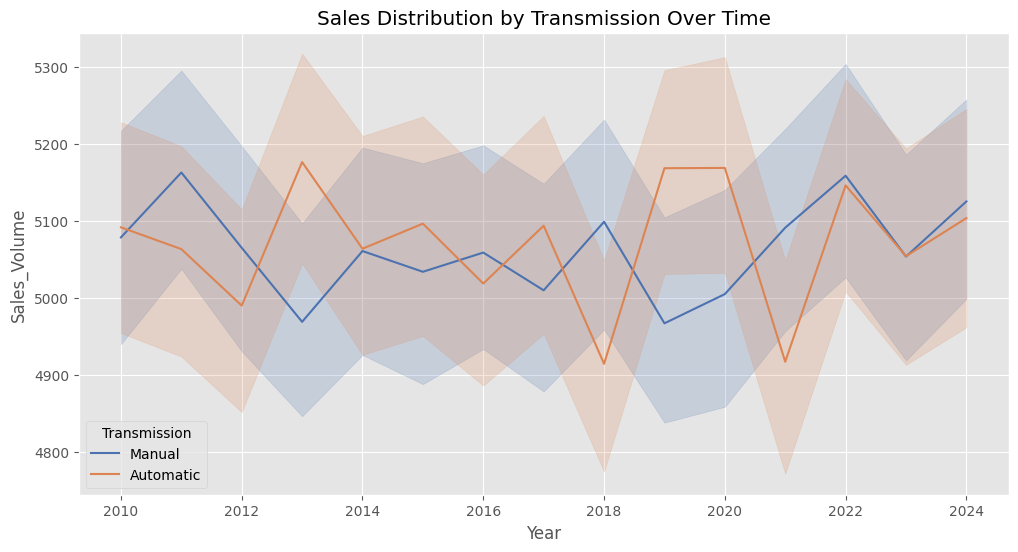

In [18]:
# plot sales transmission per year
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Sales_Volume', hue='Transmission', data=df)
plt.title('Sales Distribution by Transmission Over Time')
plt.show()

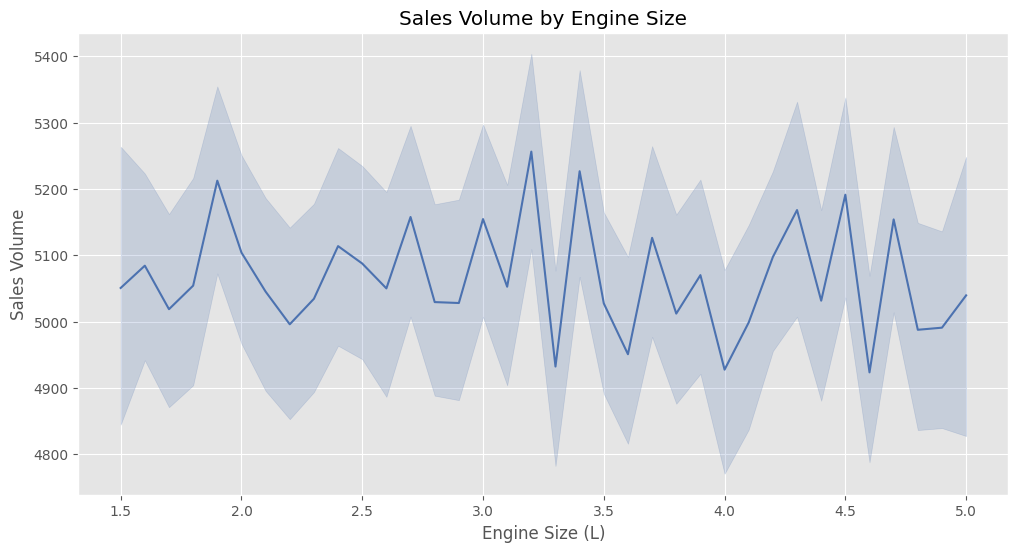

In [19]:
# SCATTER PLOT engine size vs sales volume PER YEAR
plt.figure(figsize=(12, 6))
sns.lineplot(x='Engine_Size_L', y='Sales_Volume', data=df)
plt.title('Sales Volume by Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('Sales Volume')
plt.show()

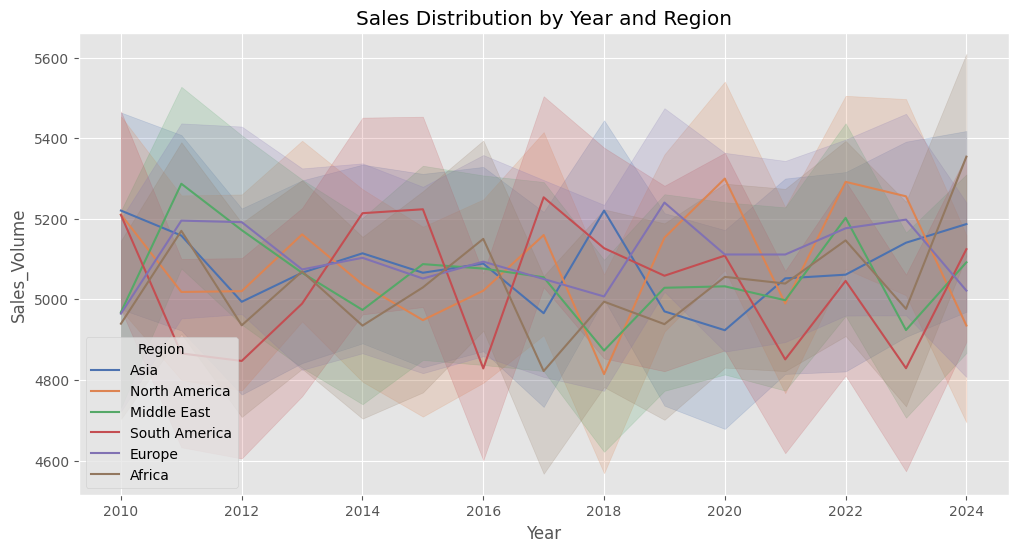

In [20]:
#plot sales per year per region
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Sales_Volume', hue='Region', data=df)
plt.title('Sales Distribution by Year and Region')
plt.show()



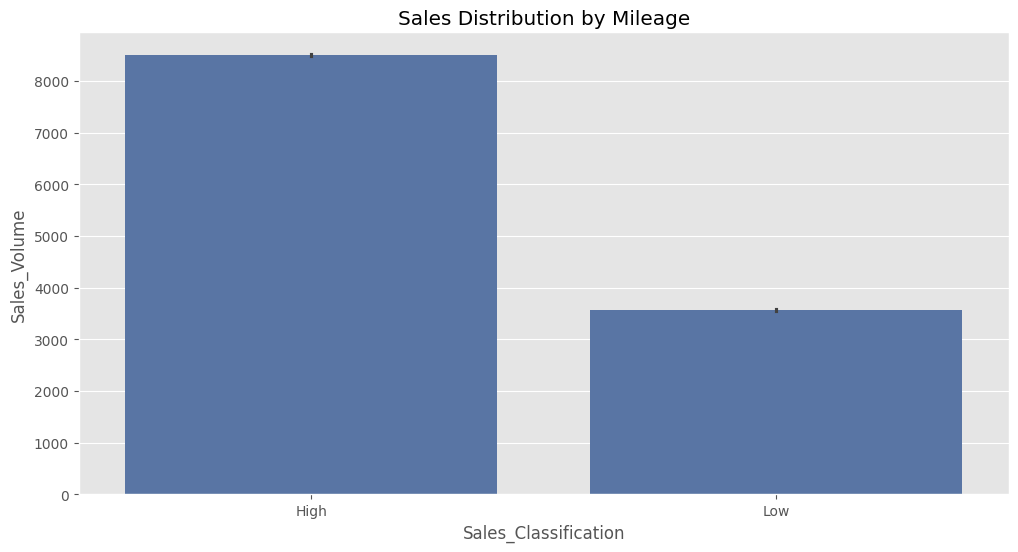

In [21]:
# sales per mileage
plt.figure(figsize=(12, 6))
sns.barplot(x='Sales_Classification', y='Sales_Volume', data=df)
plt.title('Sales Distribution by Mileage')
plt.show()

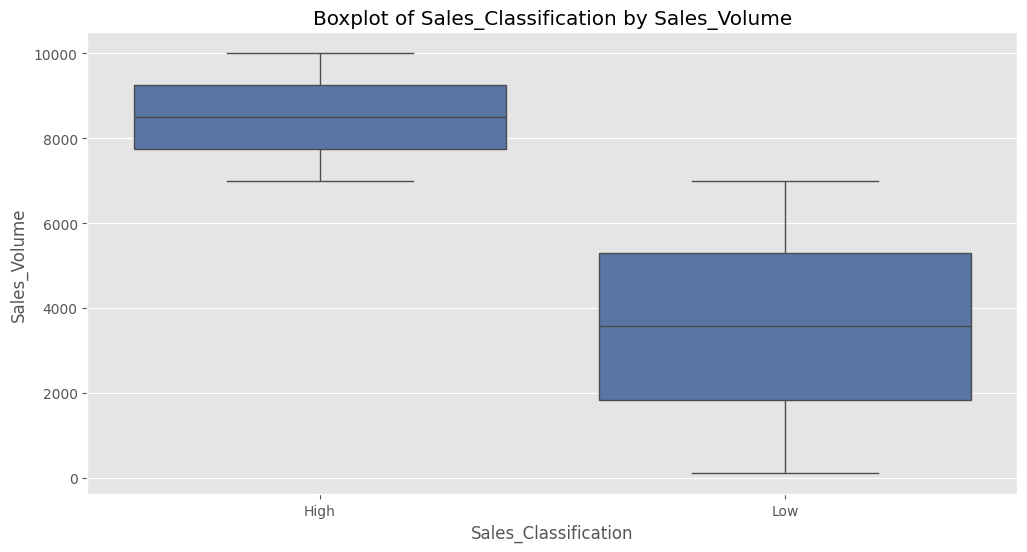

In [22]:
# Boxplot of Sales_Classification by Sales_Volume
plt.figure(figsize=(12, 6))
sns.boxplot(x='Sales_Classification', y='Sales_Volume', data=df)
plt.title('Boxplot of Sales_Classification by Sales_Volume')

plt.show()

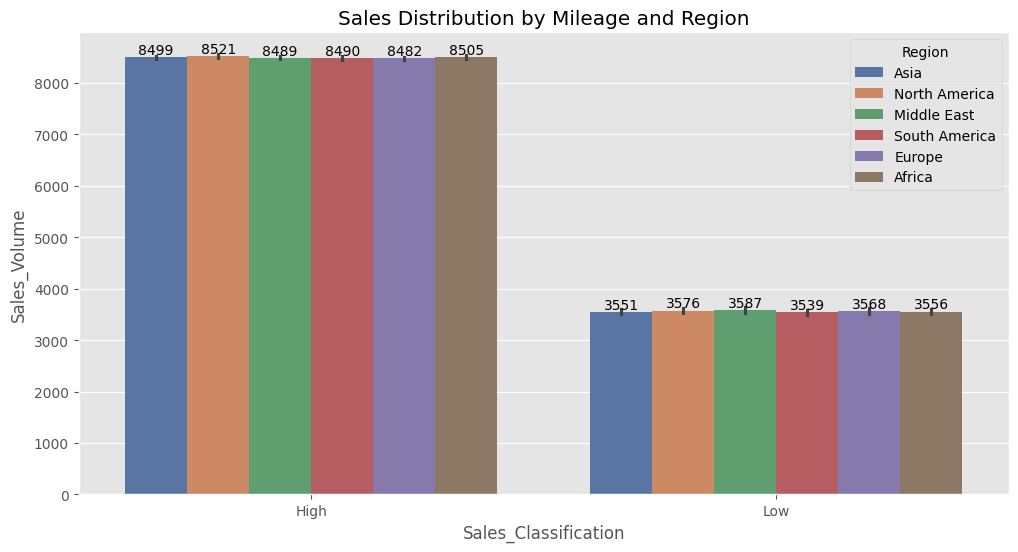

In [23]:
# sales per mileage per region
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Sales_Classification', y='Sales_Volume', hue='Region', data=df)
plt.title('Sales Distribution by Mileage and Region')

# Annotate bars with total sales values
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge')

plt.show()

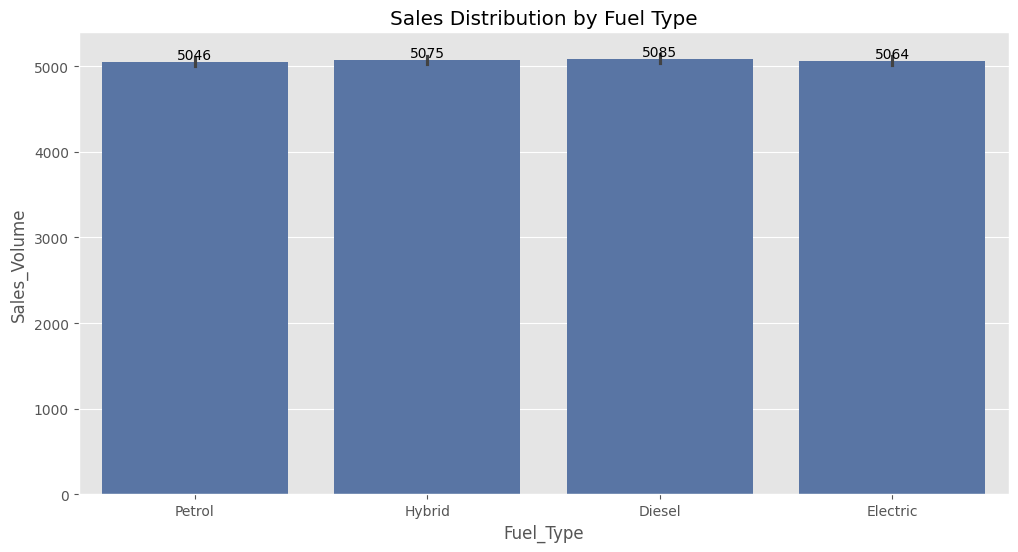

In [24]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Fuel_Type', y='Sales_Volume', data=df)
plt.title('Sales Distribution by Fuel Type')

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()


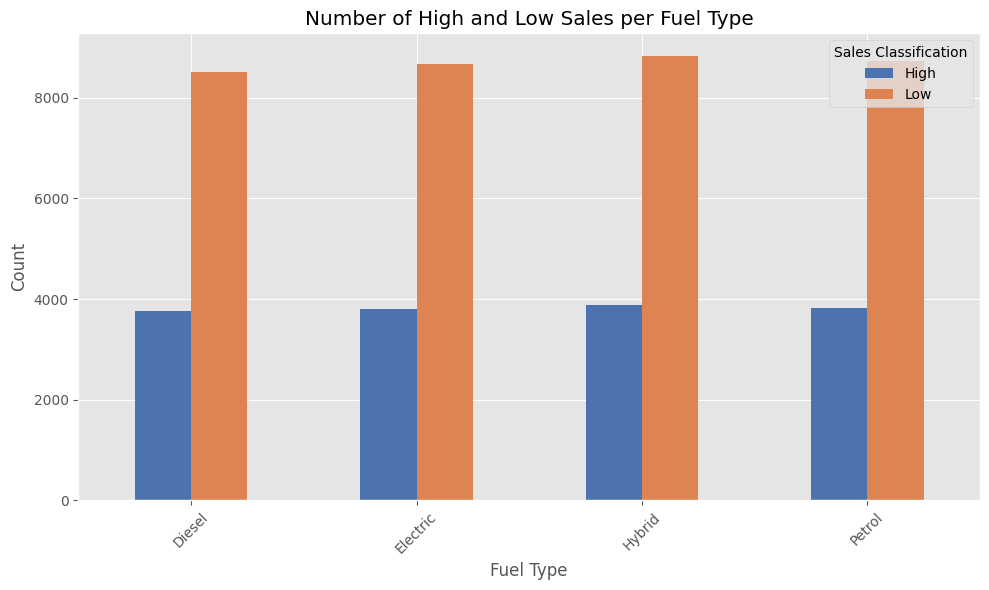

In [25]:
# Count number of high and low sales per fuel type
sales_counts = df.groupby(['Fuel_Type', 'Sales_Classification']).size().unstack(fill_value=0)

# Plot the counts
sales_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Number of High and Low Sales per Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sales Classification')
plt.tight_layout()
plt.show()

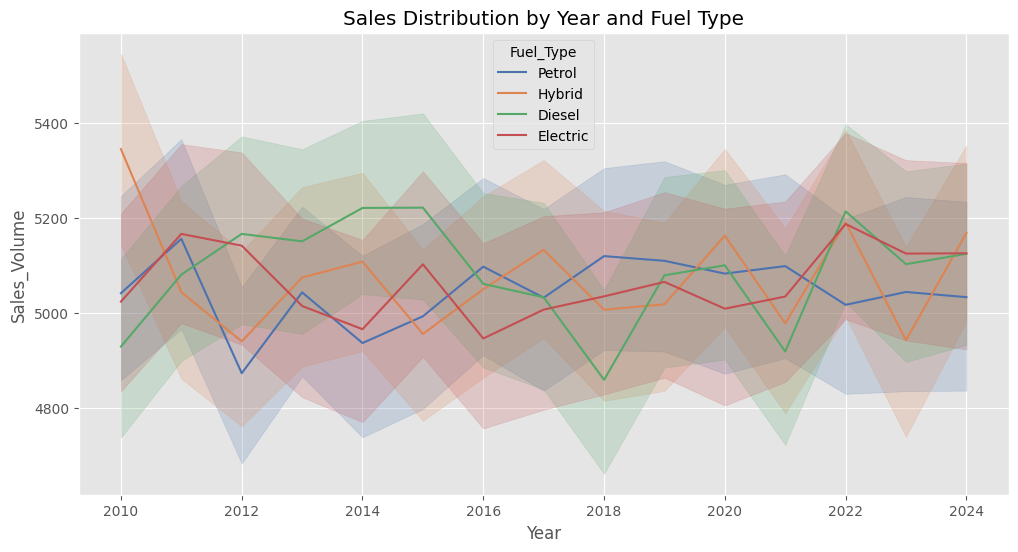

In [26]:
# sales by fuel type per year
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Sales_Volume', hue='Fuel_Type', data=df)
plt.title('Sales Distribution by Year and Fuel Type')
plt.show()


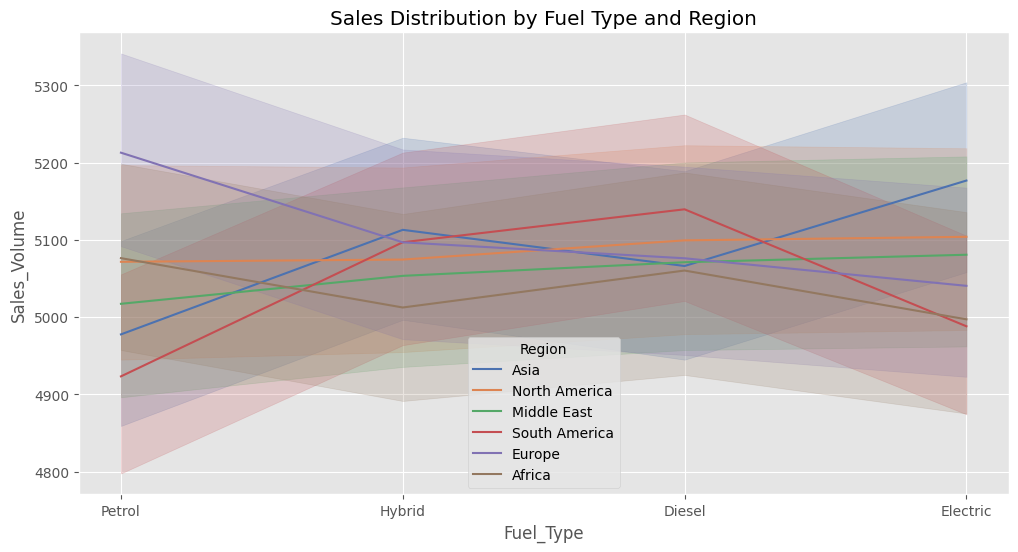

In [27]:
# sales by fuel type by region
plt.figure(figsize=(12, 6))
sns.lineplot(x='Fuel_Type', y='Sales_Volume', hue='Region', data=df)
plt.title('Sales Distribution by Fuel Type and Region')


plt.show()

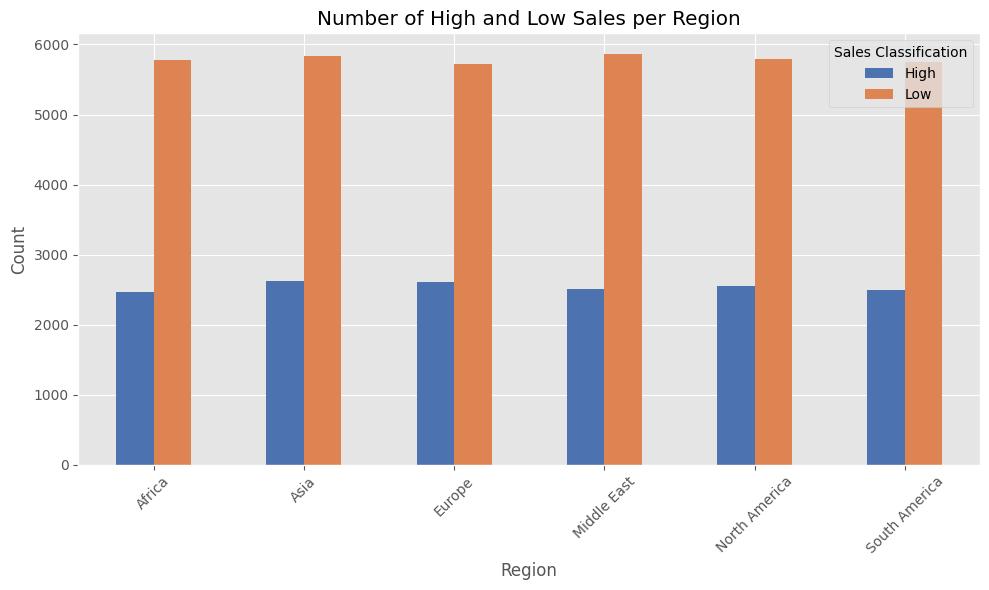

In [28]:
#Count number of high and low sales per region
sales_counts_region = df.groupby(['Region', 'Sales_Classification']).size().unstack(fill_value=0)

# Plot the counts
sales_counts_region.plot(kind='bar', figsize=(10, 6))
plt.title('Number of High and Low Sales per Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sales Classification')
plt.tight_layout()
plt.show()
